In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_test_deltaphi/tables')
SAMPLE = 'C1N2ML_M500_485_ct2_2018_MET300_SP1_evt_leading_vtx_SP1_dphiMET_vs_SP1_Max_ML_score'
# SAMPLE = 'stopML_M1000_985_ct20_2018_SP1_evt_MET_pt_corr_vs_SP1_Max_ML_score'
loCut_key = '0.00,0.00'

TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

print('Keys in the loaded table:')
for key in table.keys():
    print(key)


Keys in the loaded table:
0.00,0.00


In [6]:
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

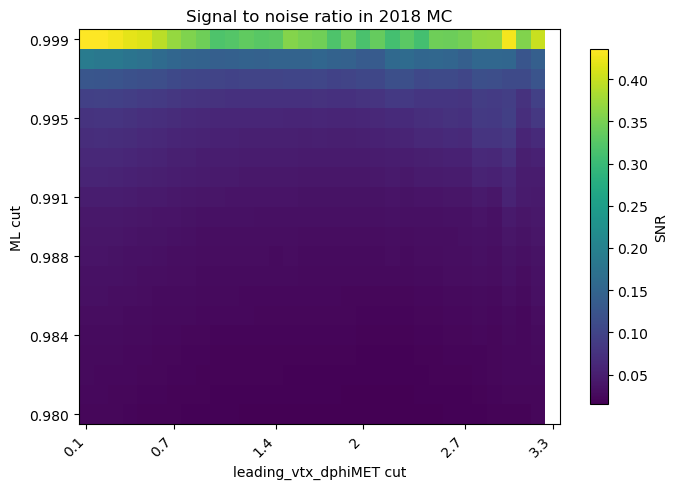

In [49]:
X_b = table[loCut_key]['sig_NA'].loc[0:,0.98:] / table[loCut_key]['bkg_NA'].loc[0:,0.98:]
X_b = X_b.loc[0:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))
pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="viridis", shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'SNR')

ax.set_xlabel("leading_vtx_dphiMET cut")
ax.set_ylabel("ML cut")
ax.set_title("Signal to noise ratio in 2018 MC")

fig.tight_layout()
plt.show()

In [8]:
X_b = -table[loCut_key]['delta_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
# absmax = np.nanmax(np.abs(C))
absmax = 20

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [9]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [10]:
table[loCut_key]['delta_A_unc'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
table[loCut_key]['delta_A'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [13]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[250:, 0.998:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [14]:
table[loCut_key]['bkg_NA'].loc[100:600,0.999:]

,0.999


In [15]:
table[loCut_key]['bkg_NA_unc'].loc[100:600,0.999:]

,0.999


In [16]:
table[loCut_key]['sig_NA'].loc[100:600,0.999:]

,0.999


In [17]:
table[loCut_key]['Z_A'].loc[100:600,1:0.999:-1].T

""
0.999


In [18]:
-table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']

,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
table[loCut_key]['bkg_NA'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
table[loCut_key]['noncl'].loc[250:,0.98:] - table[loCut_key]['noncl_unc'].loc[250:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999


In [21]:
def plot_updown(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin =  0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")
    # ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()

key = loCut_key
noncl          =  table[key]['noncl'].loc[250:,0.98:]
noncl_plus1s   =  table[key]['noncl'].loc[250:,0.98:] + table[key]['noncl_unc'].loc[250:,0.98:]
noncl_minus1s  =  table[key]['noncl'].loc[250:,0.98:] - table[key]['noncl_unc'].loc[250:,0.98:]
plot_updown(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

ValueError: zero-size array to reduction operation fmax which has no identity

### Overall Picture

In [22]:
key = loCut_key
X_b = -table[key]['delta_A']
X_b = X_b.loc[250:,:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [23]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [24]:
key = loCut_key
X_b = -table[key]['delta_A'] / table[key]['bkg_NA']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

### Significance

In [25]:
import matplotlib.ticker as mtick



key = loCut_key
X_b = table[key]['Z_A']
X_b = X_b.loc[250:, 0.998:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [26]:
X_b = table[loCut_key]['Z_noncl_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

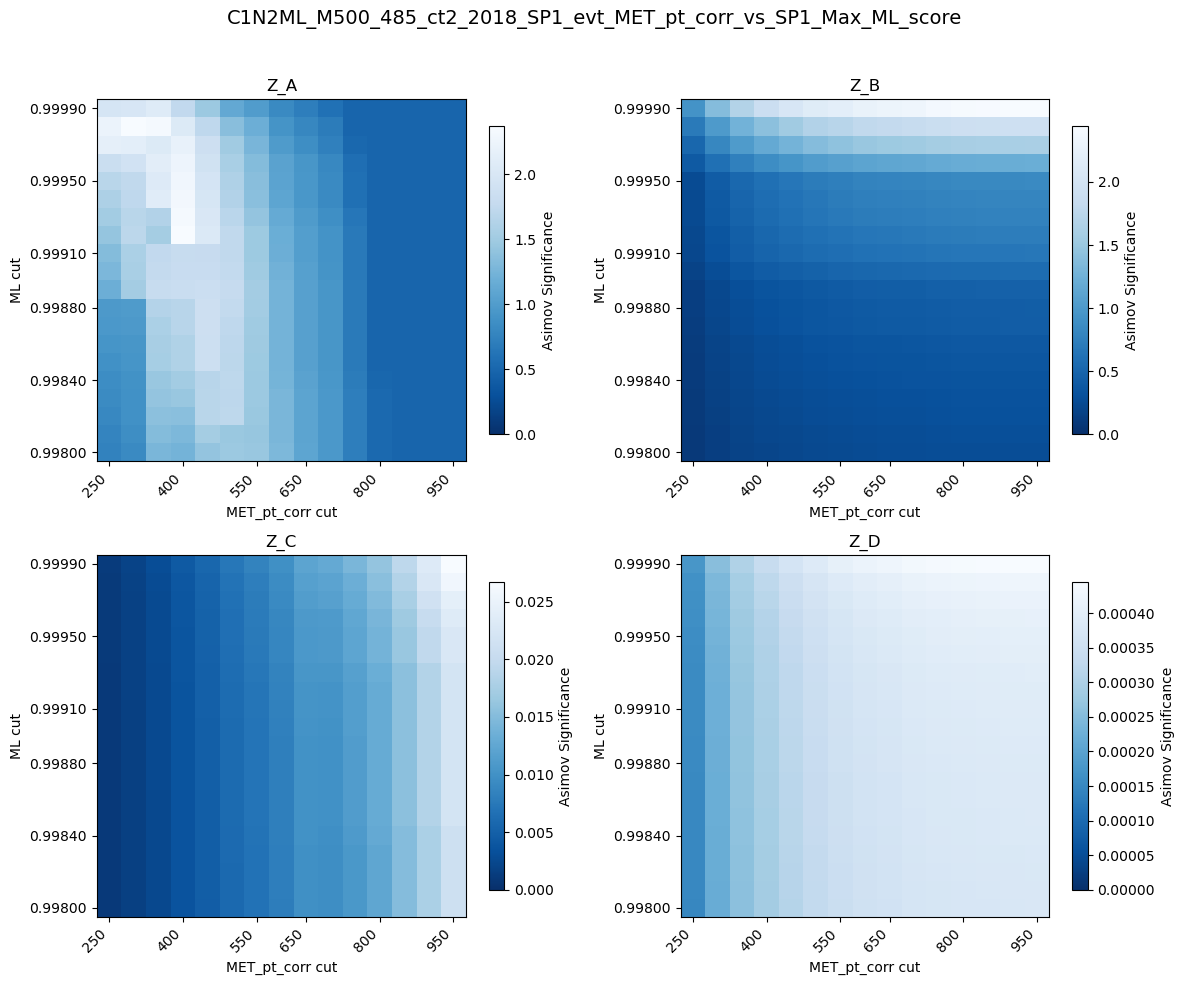

In [ ]:
import matplotlib.ticker as mtick

Z_KEYS = ["Z_A", "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK]
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [27]:
table[key]['Z_A'].loc[250:, 0.999:]

,0.999


In [28]:
x_max, y_max = table[key]['Z_A'].loc[250:, 0.999:].stack().idxmax()
print('Cut at x: ', x_max)
print('Cut at y: ', y_max)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_max, y_max]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_max, y_max]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_max, y_max]:.3f}")

ValueError: attempt to get argmax of an empty sequence

In [ ]:
x_cut, y_cut = 400, 0.9992000000000001
print('Cut at x: ', x_cut)
print('Cut at y: ', y_cut)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_cut, y_cut]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_cut, y_cut]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_cut, y_cut]:.3f}")

Cut at x:  400
Cut at y:  0.9992000000000001

B signif.: 	 0.519
B sig yield: 	 9.537
B bkg yield: 	 62.926


IndexError: index 0 is out of bounds for axis 0 with size 0

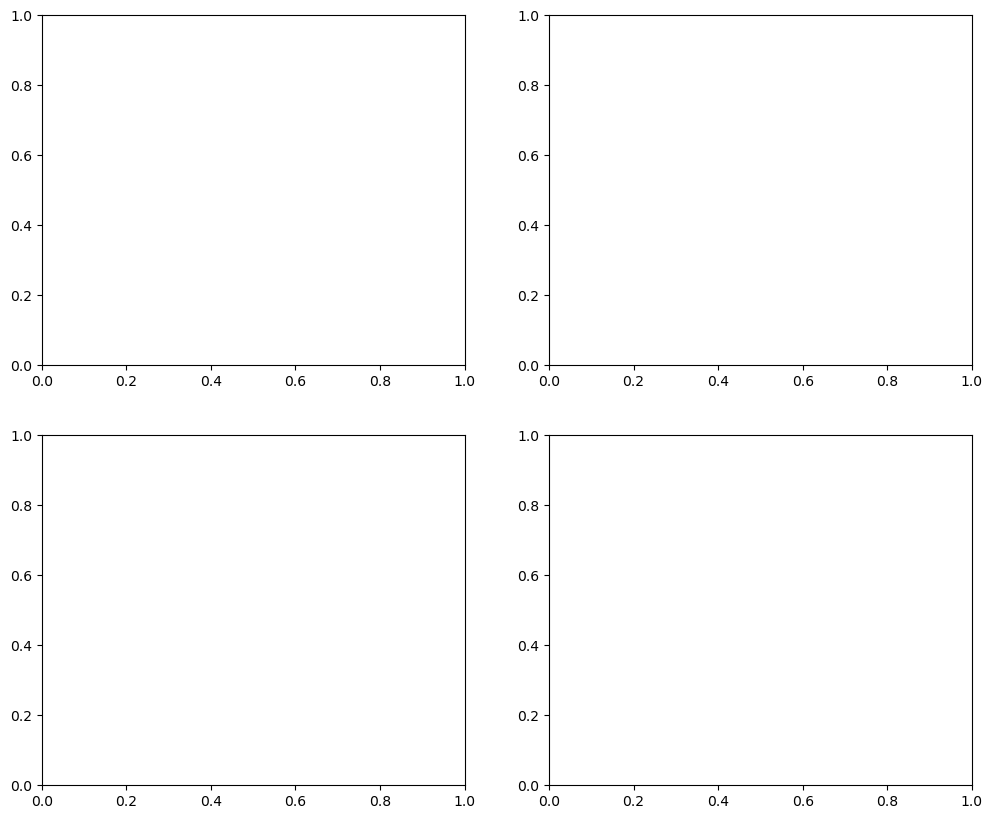

In [29]:
sig_contamination_upper_limit = 0.20

blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < sig_contamination_upper_limit)
import matplotlib.ticker as mtick

Z_KEYS = ["Z_A", "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK][blinding_mask]
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    C = np.ma.masked_invalid(C)

    absmax = np.nanmax(np.abs(C))

    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad("black")

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.text(
        0.7, 0.8, f"Signal Contamination > {100 * sig_contamination_upper_limit:.0f}%\nin B region",
        transform=ax.transAxes,
        ha="center", va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
        fontfamily="sans-serif",
        fontname="Nimbus Sans",
        bbox=dict(facecolor="black", edgecolor="none", boxstyle="round,pad=0.4"),
        zorder=10
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
(table[key]['sig_NA'] / table[key]['bkg_NA']).loc[250:, 0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
250.0,0.498915,0.548054,0.644427,0.749555,0.814258,0.886099,1.178029,2.353075,3.758510,35.690422
300.0,0.853840,0.918288,1.103276,1.063974,1.104813,1.103293,1.621204,2.379052,4.203731,31.576408
350.0,2.541509,3.093524,-27.781240,-424.512569,7.195469,7.315887,-51.872984,-25.567651,-1186.278209,-6.992950
400.0,2.119075,2.137783,8.110481,10.796664,19.758359,30.981663,-41.243399,-27.696107,-8.047923,-5.445425
450.0,4.811099,4.752267,14.685201,25.505723,-56.424951,-55.209493,-10.711151,-10.308903,-6.251917,-4.247335
500.0,4.005073,3.940953,15.135409,23.274460,22.022223,21.597252,80.447866,76.406068,inf,inf
550.0,3.397676,3.329603,15.506290,28.544520,26.924020,26.595561,64.549035,60.507237,inf,inf
600.0,24.815542,24.149827,23.799391,inf,inf,inf,inf,inf,inf,inf
650.0,19.867941,19.508064,19.508064,inf,inf,inf,inf,inf,inf,inf
700.0,17.025985,16.666109,16.666109,inf,inf,inf,inf,inf,inf,inf


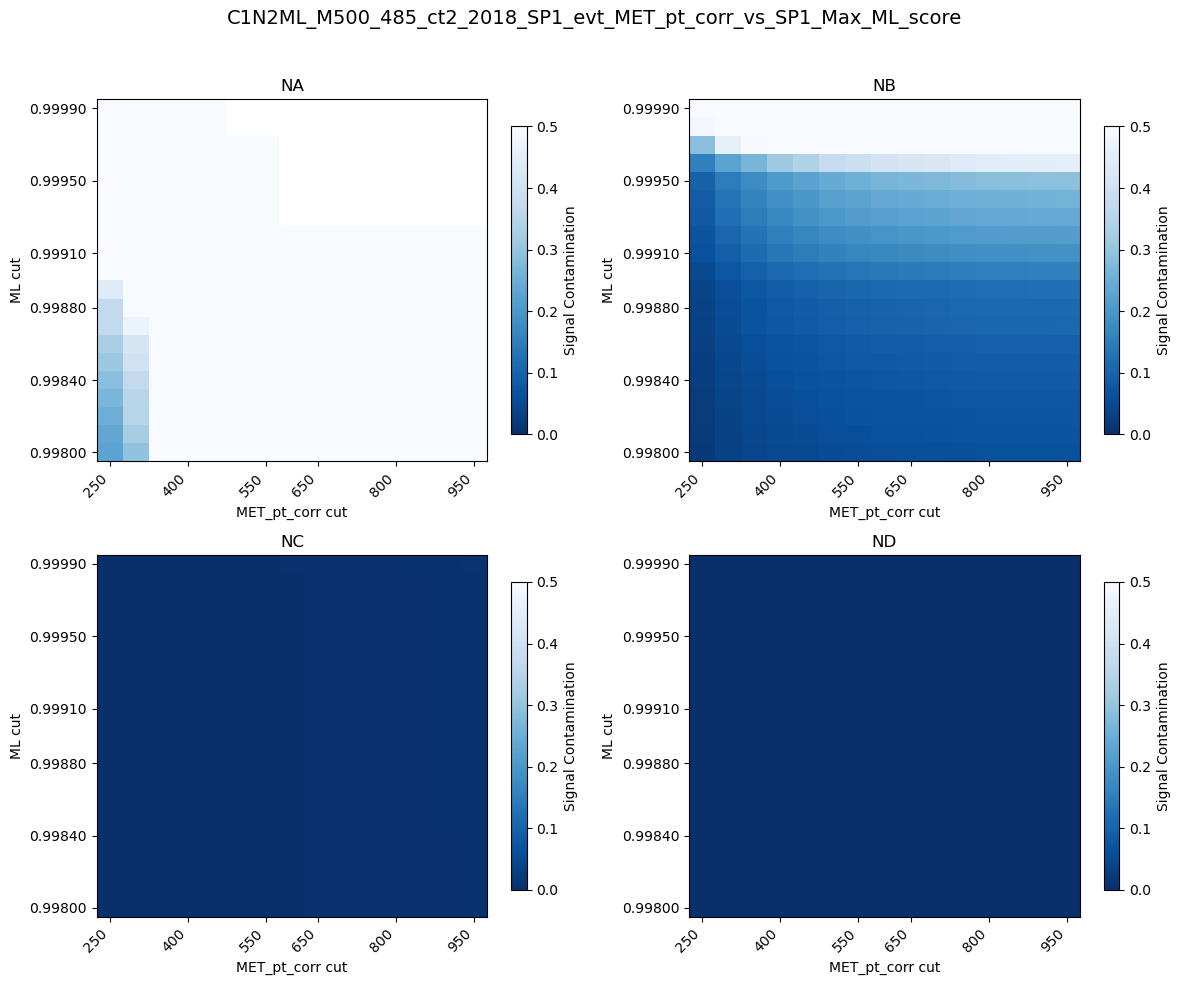

In [ ]:
blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < 0.20)
import matplotlib.ticker as mtick

Z_KEYS = ["NA", "NB", "NC", "ND"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    s = table[key][f'sig_{ZK}']
    b = table[key][f'bkg_{ZK}']
    b[b < 0] = 0.1
    X_b = s / b
    X_b = X_b.loc[250:, 0.998:]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    cmap = plt.cm.Blues_r.copy()
    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=0.5, # 50% signal contamination
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Signal Contamination")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
